### This notebook will play an RF pulse to both outputs of the QCM-RF, to be put into the frequency mixer, in order to test the phase control of the outputs

### Setup

In [1]:
# Imports
import time
import json
import matplotlib.pyplot as plt # type: ignore
import pyvisa # type: ignore
import numpy as np # type: ignore
import scipy # type: ignore
from numpy import random # type: ignore
from __future__ import annotations 
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument # type: ignore
from qblox_instruments import Cluster, ClusterType # type: ignore
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module # type: ignore

In [2]:
# Run to get cluster IP
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.9.1 with name "cluster-mm" and serial number 00015_2251_003


In [3]:
# Connect to cluster
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'

# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]

cluster.led_brightness('medium')

# reset cluster and print cluster status
cluster.reset()
print(cluster.get_system_status())

Status: OKAY, Flags: NONE, Slot flags: NONE


In [4]:
# Define which modules will be used
modules
rf_module = modules[6]
qrm_module = modules[4]

In [5]:
# Check QCM-RF
print("\nQCM: {}\nQRM: {}\nRF: {}".format(rf_module.is_qcm_type, rf_module.is_qrm_type, rf_module.is_rf_type))


QCM: True
QRM: False
RF: True


In [6]:
# Check QRM
print("\nQCM: {}\nQRM: {}\nRF: {}".format(qrm_module.is_qcm_type, qrm_module.is_qrm_type, qrm_module.is_rf_type))


QCM: False
QRM: True
RF: False


### End of setup

---
---

### Function to run the experiment for one iteration

In [ ]:
def run_rabi_sequence(rf_pulse_length):

	waveforms_rf = {
		"block": {		# Block to be modulated and played as the RF pulse in step 4.
			"data": [1.0 for i in range(rf_pulse_length)],
			"index": 0
		}
	}

	acquisitions = {
    	"acq": {"num_bins": 1, "index": 0},
	}

	# RF sequence, also sets marker for viewing on the oscilloscope
	seq_rf = f"""
	  	wait_sync	4
		  
	  	set_mrk	  	{0b1111}

		set_ph		{0}		# Keep this phase at 0, control the other
	  	play		0,0,{rf_pulse_length}	# Play both pulses at the same time
	
	  	set_mrk	  	{0b0000}
		upd_param	4

		stop
	"""

	seq_reference = f"""
	  	wait_sync	4
		  
		set_ph		{int(0)}	# Adjust this phase to get a different phase out of the mixer
	  	play		0,0,{rf_pulse_length}	# Play both pulses at the same time
	
		stop
	"""

	seq_in = f"""
		wait_sync	4

		acquire		0,0,{rf_pulse_length}	# If using the QRM for acquisition, acquire when the pulses start

		stop
	"""

	# UPLOAD SEQUENCES
	sequence_rf = {
		"waveforms": waveforms_rf,
		"weights": {},
		"acquisitions": {},
		"program": seq_rf,
	}

	sequence_reference = {
		"waveforms": waveforms_rf,
		"weights": {},
		"acquisitions": {},
		"program": seq_reference,
	}

	sequence_in = {
		"waveforms": {},
		"weights": {},
		"acquisitions": acquisitions,
		"program": seq_in,
	}

	# Upload sequences to their respective sequencers
	rf_module.sequencer0.sequence(sequence_rf)
	rf_module.sequencer1.sequence(sequence_reference)
	qrm_module.sequencer0.sequence(sequence_in)

	# Disconnect previous output connections outputs
	rf_module.disconnect_outputs()
	qrm_module.disconnect_inputs()
	qrm_module.disconnect_outputs()

	# Connect outputs and inputs
	rf_module.sequencer0.connect_out0(True)
	rf_module.sequencer1.connect_out1(True)
	qrm_module.sequencer0.connect_acq_I("in0")

	# Delete previous acquisition data
	qrm_module.delete_acquisition_data(0, "acq")

	qrm_module.scope_acq_sequencer_select(0) # Configure scope mode
	qrm_module.scope_acq_trigger_mode_path0("sequencer") # Set the scope acquisition to trigger off of the sequnecer acquire command

	# Enable NCO and LO modulation and set their respective frequencies for output 0
	rf_module.sequencer0.mod_en_awg(True)
	rf_module.out0_lo_en(True)
	rf_module.sequencer0.nco_freq(100e6)
	rf_module.out0_lo_freq(2e9)

	# Enable NCO and LO modulation and set their respective frequencies for output 1
	rf_module.sequencer1.mod_en_awg(True)
	rf_module.out1_lo_en(True)
	rf_module.sequencer1.nco_freq(100e6)
	rf_module.out1_lo_freq(2e9)

	# Automatic mixer calibration
	# rf_module.out0_lo_cal()
	# rf_module.out1_lo_cal()
	# rf_module.sequencer0.sideband_cal()
	# rf_module.sequencer1.sideband_cal()

	rf_module.sequencer0.sync_en(True)	# Enable sync
	rf_module.sequencer1.sync_en(True)	# Enable sync
	qrm_module.sequencer0.sync_en(True)	# Enable sync

	rf_module.arm_sequencer(0)  # arm rf sequencer 0
	rf_module.arm_sequencer(1)  # arm rf sequencer 1
	qrm_module.arm_sequencer(0)	# arm qrm sequncer 0

	cluster.start_sequencer()	# Run the sequence

	qrm_module.get_acquisition_status(0) # Wait for the sequencer to stop with a timeout period of one minute.
	qrm_module.store_scope_acquisition(0, 'acq') # Move acquisition data from temporary memory to acquisition list.
	data = qrm_module.get_acquisitions(0) # Get acquisition list from instrument.

	# Print status of each sequencer used.
	print("QCM-RF sequencer 0: " + str(rf_module.get_sequencer_status(0)))
	print("QCM-RF sequencer 1: " + str(rf_module.get_sequencer_status(1)))
	print("QRM sequencer 0: " + str(rf_module.get_sequencer_status(0)))

	return data

### Defining frequency, durations and looping through the pulse sequences

In [22]:
# Experiment variables
rf_pulse_length_ = 15000	# ns	# Length of the RF pulse (step 4)

readout_data = run_rabi_sequence(rf_pulse_length_)	# Run the sequence

QCM-RF sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM-RF sequencer 1: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []


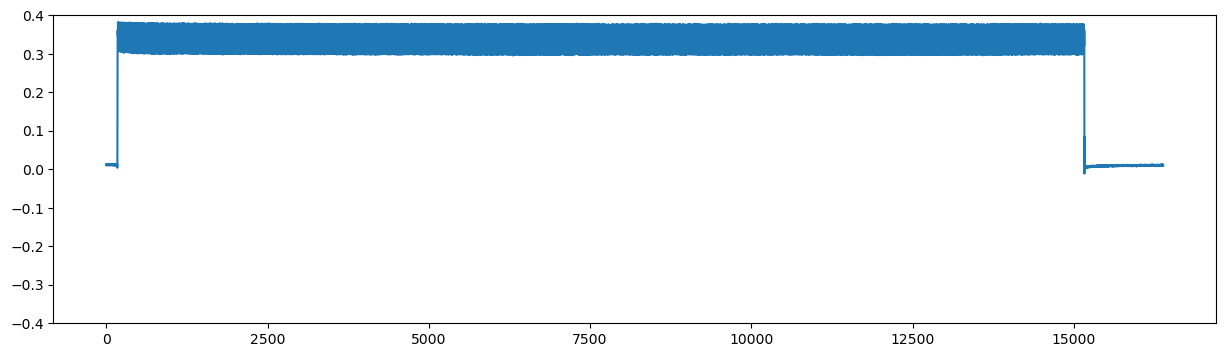

0.382


In [23]:
# Plotting results
data = readout_data['acq']['acquisition']['scope']['path0']['data']

fig, ax = plt.subplots(1, 1, figsize = (15, 4))
ax.plot(data[:])
ax.set_ylim([-0.4, 0.4])
plt.show()

print("{:.3}".format(max(data)))

### Stopping

In [5]:
rf_module.stop_sequencer(0)
rf_module.stop_sequencer(1)

print("QCM-RF sequencer 0: " + str(rf_module.get_sequencer_status(0)))
print("QCM-RF sequencer 1: " + str(rf_module.get_sequencer_status(1)))

cluster.reset()
print(cluster.get_system_status())

QCM-RF sequencer 0: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
QCM-RF sequencer 1: Status: OKAY, State: STOPPED, Info Flags: NONE, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE


### Reset and configure oscilloscope

In [19]:
scope.write(f'TIME_DIV {2e-6} S')		# Set the time scale on all oscilloscope channels
scope.write(f'C1:VOLT_DIV {0.5} V')		# Set the voltage scale on channel 1
scope.write(f'C2:VOLT_DIV {0.5} V')		# Set the voltage scale on channel 1
scope.write(f'C3:VOLT_DIV {0.5} V')		# Set the voltage scale on channel 3
scope.write(f'TRIG_DELAY {-0.8e-5}')	# Set the time scale left/right on the display
scope.write(f'TRIG_MODE SINGLE')		# Set the trigger mode to "single" in order to take one acquisition

18